# **Project Name**    - Mental Health in Tech Survey - EDA



##### **Project Type**    - EDA
##### **Contribution**    - Individual

# **Project Summary -**

This project performs exploratory data analysis on the 2014 OSMI (Open Sourcing Mental Illness) Mental Health in Tech survey, which captures attitudes towards mental health and the frequency of mental health conditions among employees in the tech industry. The dataset contains 1259 responses across 27 features, including demographic details (age, gender, country, state), workplace characteristics (company size, remote work status), and attitudinal responses (comfort discussing mental health with supervisors/coworkers, awareness of company benefits and care options, and perceived stigma or consequences of disclosure).

The analysis began with data cleaning, since the raw survey data contained several quality issues typical of open-text survey fields. The Age column had unrealistic values, including negative numbers and entries in the billions, which were filtered to a realistic range of 18-75 years. The Gender column had 49 inconsistent free-text variants (e.g., "Male", "male", "M", "Cis Male") that were standardized into three categories: Male, Female, and Other. Missing values were also addressed: the largely-empty comments column was dropped, self_employed was imputed with its mode, work_interfere missing values were treated as "Not applicable" (indicating no condition to interfere with work), and missing state entries were labeled "Unknown" (mostly non-US respondents).

Following cleaning, 15 visualizations were created to explore the data from multiple angles: demographic distributions (age, gender), treatment-seeking behavior, the relationship between family history and treatment, work interference severity, company-level factors (size, benefits, care options, anonymity, leave policies), interpersonal comfort discussing mental health (with coworkers vs. supervisors), remote work's relationship with treatment, a correlation heatmap of encoded variables, and a pair plot of key features.

Key findings show that family history of mental illness, work interference severity, and awareness of care options are stronger predictors of treatment-seeking than demographic factors like age or gender. A recurring pattern across several charts was that a large portion of respondents answered "Don't know" or "Not sure" regarding benefits, anonymity, and leave policies - more so than a definitive "No." This points to a company communication problem as much as a policy gap: employees may not know what support is available to them even when it exists. Additionally, a notable share of respondents feared negative consequences from disclosing mental health issues at work, reflecting ongoing workplace stigma.

These insights suggest that tech companies looking to improve employee mental health outcomes should focus not just on creating supportive policies, but on communicating them clearly and consistently, and on actively working to reduce stigma around disclosure. The near-even split between those who have and haven't sought treatment (about half) indicates this is not a marginal issue but a mainstream workplace concern deserving structured, ongoing attention.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


Mental health remains a significant but often under-addressed issue in the tech industry, where high-pressure work environments and stigma can prevent employees from seeking help. This project analyzes survey data to understand current attitudes towards mental health in tech workplaces, identify factors influencing whether employees seek treatment, and uncover gaps in awareness of company-provided mental health resources.

#### **Define Your Business Objective?**

To identify the key demographic, workplace, and attitudinal factors that influence mental health treatment-seeking behavior among tech employees, and to provide insights that can help companies design more effective, well-communicated mental health support systems.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")

### Dataset Loading

In [28]:
# Load Dataset
df = pd.read_csv('survey.csv')

### Dataset First View

In [29]:
# Dataset First Look
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


### Dataset Rows & Columns count

In [30]:
# Dataset Rows & Columns count
print("Shape:", df.shape)

Shape: (1259, 27)


### Dataset Information

In [33]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Timestamp                  1259 non-null   str  
 1   Age                        1259 non-null   int64
 2   Gender                     1259 non-null   str  
 3   Country                    1259 non-null   str  
 4   state                      744 non-null    str  
 5   self_employed              1241 non-null   str  
 6   family_history             1259 non-null   str  
 7   treatment                  1259 non-null   str  
 8   work_interfere             995 non-null    str  
 9   no_employees               1259 non-null   str  
 10  remote_work                1259 non-null   str  
 11  tech_company               1259 non-null   str  
 12  benefits                   1259 non-null   str  
 13  care_options               1259 non-null   str  
 14  wellness_program           1259 non

#### Duplicate Values

In [ ]:

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


#### Missing Values/Null Values

In [34]:
df.isnull().sum()

Timestamp                       0
Age                             0
Gender                          0
Country                         0
state                         515
self_employed                  18
family_history                  0
treatment                       0
work_interfere                264
no_employees                    0
remote_work                     0
tech_company                    0
benefits                        0
care_options                    0
wellness_program                0
seek_help                       0
anonymity                       0
leave                           0
mental_health_consequence       0
phys_health_consequence         0
coworkers                       0
supervisor                      0
mental_health_interview         0
phys_health_interview           0
mental_vs_physical              0
obs_consequence                 0
comments                     1095
dtype: int64

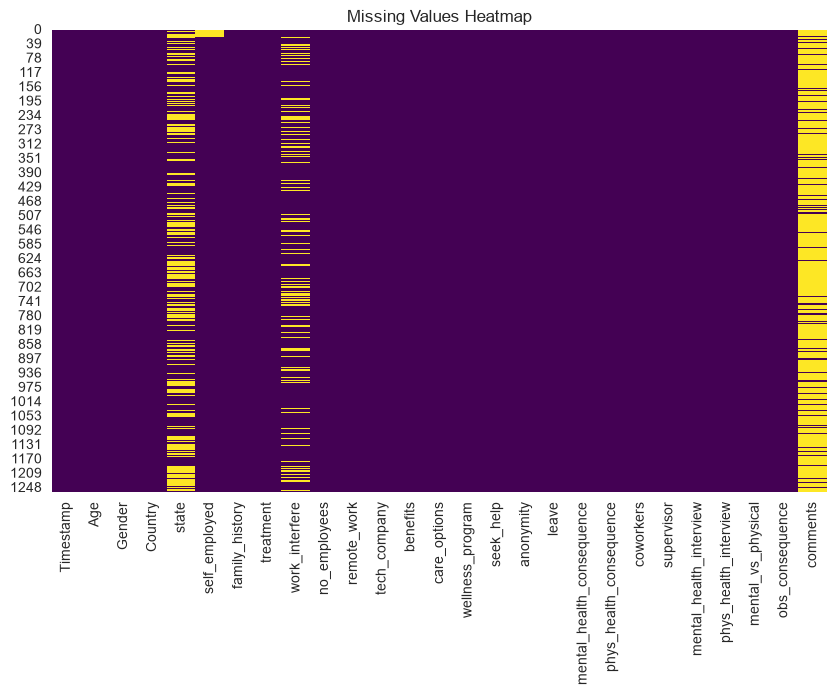

In [35]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

### What did i know about this dataset?

The dataset contains 1259 rows and 27 columns, sourced from the 2014 OSMI Mental Health in Tech survey. Out of 27 columns, 26 are categorical (object/string type) and only Age is numeric, so most analysis and visualizations will rely on frequency counts and category comparisons rather than numeric distributions.

Several columns have missing values: comments has the most missing data (1095 out of 1259, ~87%), followed by state (515 missing, ~41%), work_interfere (264 missing, ~21%), and self_employed (18 missing, ~1.4%). All other columns are fully populated. The high missingness in comments and state suggests these are optional or region-specific fields, and will need careful handling during data wrangling — likely dropping comments and imputing or categorizing the others.

No duplicate rows are present in the dataset.

## ***2. Understanding Your Variables***

In [36]:
df.columns

Index(['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed',
       'family_history', 'treatment', 'work_interfere', 'no_employees',
       'remote_work', 'tech_company', 'benefits', 'care_options',
       'wellness_program', 'seek_help', 'anonymity', 'leave',
       'mental_health_consequence', 'phys_health_consequence', 'coworkers',
       'supervisor', 'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence', 'comments'],
      dtype='str')

In [37]:
df.describe(include='all')

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
count,1259,1.259000e+03,1259,1259,744,1241,1259,1259,995,1259,...,1259,1259,1259,1259,1259,1259,1259,1259,1259,164
unique,1246,NaN,49,48,45,2,2,2,4,6,...,5,3,3,3,3,3,3,3,2,160
top,2014-08-27 12:31:41,NaN,Male,United States,CA,No,No,Yes,Sometimes,6-25,...,Don't know,No,No,Some of them,Yes,No,Maybe,Don't know,No,* Small family business - YMMV.
freq,2,NaN,615,751,138,1095,767,637,465,290,...,563,490,925,774,516,1008,557,576,1075,5
mean,NaN,7.942815e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,2.818299e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,-1.726000e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,2.700000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,3.100000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,3.600000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Variables Description

The dataset has 27 columns capturing demographic details (Age, Gender, Country, state) and workplace mental health attitudes/policies (treatment, family_history, work_interfere, benefits, care_options, wellness_program, seek_help, anonymity, leave, mental_health_consequence, coworkers, supervisor, etc.). Most columns are categorical with 2–6 response options (mainly Yes/No/Maybe or similar scales), except Age (numeric) and free-text fields like Timestamp, state, Country, and comments. Key columns of interest include treatment (whether the respondent sought mental health treatment) and work_interfere (whether their condition interferes with work), which are likely central to the analysis.

### Check Unique Values for each variable.

In [55]:
for col in df.columns:
    print(col, "->", df[col].nunique())

Timestamp -> 1246
Age -> 53
Gender -> 49
Country -> 48
state -> 45
self_employed -> 2
family_history -> 2
treatment -> 2
work_interfere -> 4
no_employees -> 6
remote_work -> 2
tech_company -> 2
benefits -> 3
care_options -> 3
wellness_program -> 3
seek_help -> 3
anonymity -> 3
leave -> 5
mental_health_consequence -> 3
phys_health_consequence -> 3
coworkers -> 3
supervisor -> 3
mental_health_interview -> 3
phys_health_interview -> 3
mental_vs_physical -> 3
obs_consequence -> 2
comments -> 160


## 3. ***Data Wrangling***

### Data Wrangling Code

In [56]:
# 1. Fix Age - keep only realistic values (18 to 75)
df = df[(df['Age'] >= 18) & (df['Age'] <= 75)]
print("Shape after Age cleaning:", df.shape)

Shape after Age cleaning: (1251, 27)


In [57]:
# 2. Clean Gender - standardize into Male, Female, Other
df['Gender'] = df['Gender'].str.strip().str.lower()

male_terms = ['male', 'm', 'man', 'cis male', 'male (cis)', 'cis man',
              'mail', 'malr', 'make', 'msle', 'guy (-ish) ^_^', 'male-ish']
female_terms = ['female', 'f', 'woman', 'cis female', 'cis-female/femme',
                'female (cis)', 'femake', 'femail', 'cis woman']

def map_gender(g):
    if g in male_terms:
        return 'Male'
    elif g in female_terms:
        return 'Female'
    else:
        return 'Other'

df['Gender'] = df['Gender'].apply(map_gender)
df['Gender'].value_counts()

Gender
Male      985
Female    247
Other      19
Name: count, dtype: int64

In [58]:
# 3. Handle missing values

# comments - drop column (87% missing, mostly free text, not useful for EDA)
df = df.drop(columns=['comments'])

# self_employed - only 18 missing, fill with mode
df['self_employed'] = df['self_employed'].fillna(df['self_employed'].mode()[0])

# work_interfere - missing likely means "did not experience interference" (no condition to interfere with)
df['work_interfere'] = df['work_interfere'].fillna('Not applicable')

# state - only relevant for US respondents, missing means non-US; keep as 'Unknown'
df['state'] = df['state'].fillna('Unknown')

df.isnull().sum()

Timestamp                    0
Age                          0
Gender                       0
Country                      0
state                        0
self_employed                0
family_history               0
treatment                    0
work_interfere               0
no_employees                 0
remote_work                  0
tech_company                 0
benefits                     0
care_options                 0
wellness_program             0
seek_help                    0
anonymity                    0
leave                        0
mental_health_consequence    0
phys_health_consequence      0
coworkers                    0
supervisor                   0
mental_health_interview      0
phys_health_interview        0
mental_vs_physical           0
obs_consequence              0
dtype: int64

### What all manipulations have you done and insights you found?

During data wrangling, the Age column was cleaned by removing unrealistic values (negative numbers and values in billions), keeping only ages between 18 and 75 — this removed 8 rows. The Gender column, which originally had 49 inconsistent free-text variants, was standardized into three categories: Male, Female, and Other. The comments column was dropped since it was 87% missing and consisted of unstructured free text not suitable for this analysis. Missing values in self_employed were filled with the mode (most frequent value), work_interfere missing values were filled with "Not applicable" (likely indicating respondents without a mental health condition), and missing state values were filled with "Unknown" (mostly non-US respondents, where state doesn't apply). After these steps, the dataset has no missing values and is ready for analysis.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

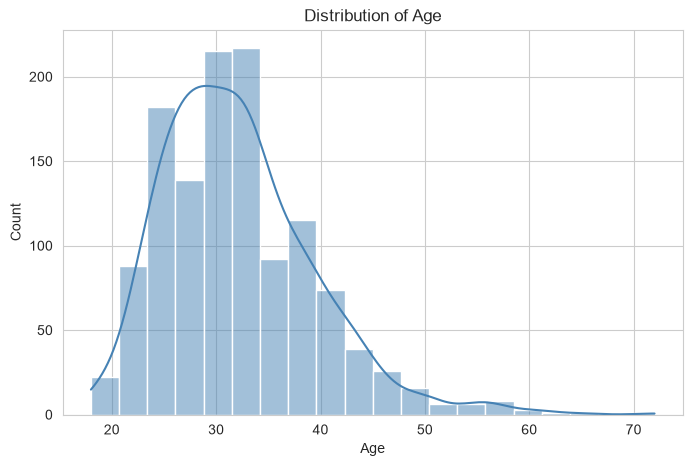

In [59]:
#### Chart 1 - Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True, color='steelblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with KDE was chosen because Age is the only continuous numeric variable, and this shows both the distribution shape and density in one view.

##### 2. What is/are the insight(s) found from the chart?

Most respondents are concentrated between their mid-20s and mid-30s, indicating the survey population skews toward early/mid-career tech professionals.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

this helps target mental health initiatives at the age group most represented in the tech workforce, rather than designing generic, one-size-fits-all programs.

#### Chart - 2

C:\Users\ASUS\AppData\Local\Temp\ipykernel_10472\3775190899.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', order=df['Gender'].value_counts().index, palette='Set2')


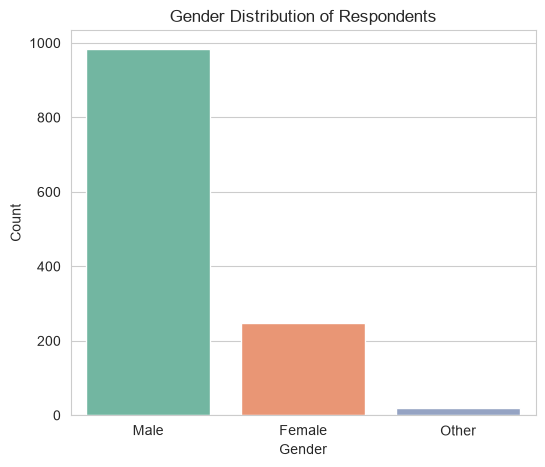

In [60]:
# Chart 2 - Gender Distribution
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='Gender', order=df['Gender'].value_counts().index, palette='Set2')
plt.title('Gender Distribution of Respondents')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

##### 1. Why did you pick the specific chart?

A count plot was used since Gender is categorical, and count plots clearly compare frequency across categories.

##### 2. What is/are the insight(s) found from the chart?

The respondent base is heavily male-dominated, with far fewer female and "Other" respondents.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is more of a data limitation than a clear positive/negative — conclusions about gender-based mental health trends should be treated cautiously due to the imbalance, and future outreach may need to specifically target underrepresented groups for more balanced data.

#### Chart - 3

C:\Users\ASUS\AppData\Local\Temp\ipykernel_10472\3509244387.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='treatment', palette='Set1')


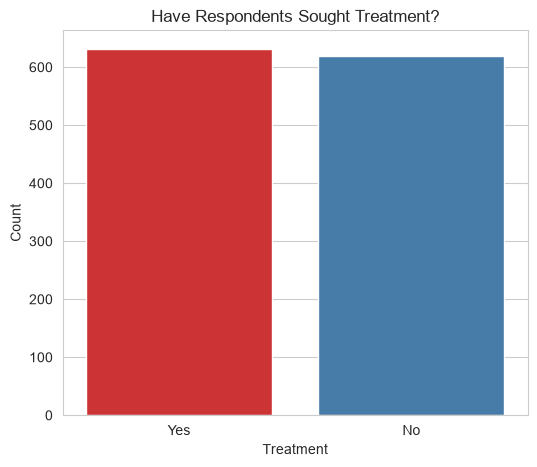

In [61]:
# Chart 3 - Treatment Sought (Yes/No)
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='treatment', palette='Set1')
plt.title('Have Respondents Sought Treatment?')
plt.xlabel('Treatment')
plt.ylabel('Count')
plt.show()

##### 1. Why did you pick the specific chart?

A count plot suits this binary Yes/No categorical variable well for a direct visual comparison.

##### 2. What is/are the insight(s) found from the chart?

Respondents are almost evenly split between having sought treatment and not — roughly half of surveyed tech employees have pursued mental health treatment.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — this signals meaningful demand for mental health support in tech workplaces, reinforcing the case for employers to invest in accessible mental health benefits and reduce stigma.

#### Chart - 4

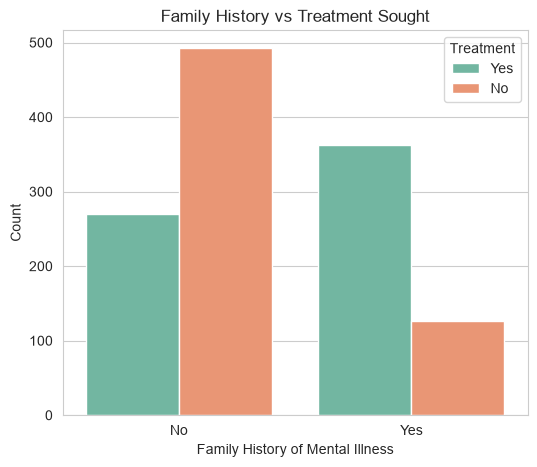

In [62]:
# Chart 4 - Family History vs Treatment
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='family_history', hue='treatment', palette='Set2')
plt.title('Family History vs Treatment Sought')
plt.xlabel('Family History of Mental Illness')
plt.ylabel('Count')
plt.legend(title='Treatment')
plt.show()

##### 1. Why did you pick the specific chart?

Company Size (no_employees) Distribution

##### 2. What is/are the insight(s) found from the chart?

Respondents with a family history of mental illness are considerably more likely to have sought treatment, while those without a family history show a much smaller proportion seeking treatment.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — this confirms family history as a strong predictor of treatment-seeking behavior, which employers/HR teams could use to design more targeted, proactive mental health outreach rather than generic programs.

#### Chart - 5

C:\Users\ASUS\AppData\Local\Temp\ipykernel_10472\3235873567.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='work_interfere', order=[o for o in order if o in df['work_interfere'].unique()], palette='mako')


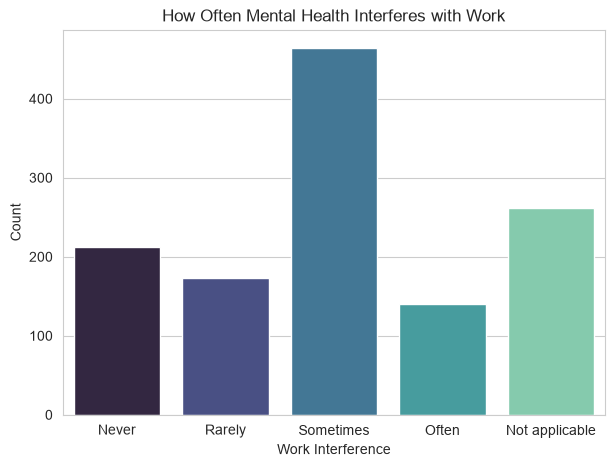

In [63]:
# Chart 5 - Work Interference Levels
plt.figure(figsize=(7,5))
order = ['Never', 'Rarely', 'Sometimes', 'Often', 'Not applicable']
sns.countplot(data=df, x='work_interfere', order=[o for o in order if o in df['work_interfere'].unique()], palette='mako')
plt.title('How Often Mental Health Interferes with Work')
plt.xlabel('Work Interference')
plt.ylabel('Count')
plt.show()

##### 1. Why did you pick the specific chart?

A count plot ordered by severity ("Never" to "Often") makes it easy to see how mental health issues affect work at different intensity levels.

##### 2. What is/are the insight(s) found from the chart?

"Sometimes" is the most common response among those with a condition, suggesting mental health issues intermittently — rather than constantly — affect productivity for most respondents.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — this shows that even occasional interference is common enough to warrant workplace support systems (flexible leave, check-ins), since the issue isn't limited to a small edge-case group.

#### Chart - 6

C:\Users\ASUS\AppData\Local\Temp\ipykernel_10472\3006987096.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='no_employees', order=[o for o in order6 if o in df['no_employees'].unique()], palette='crest')


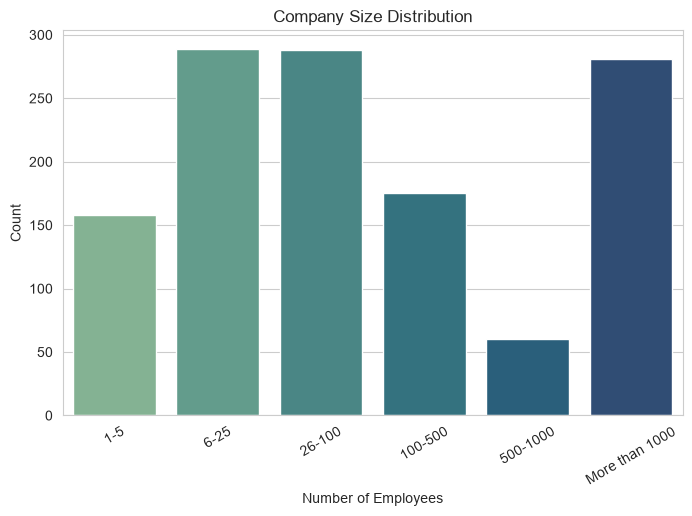

In [64]:
# Chart 6 - Company Size (no_employees) Distribution
plt.figure(figsize=(8,5))
order6 = ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000']
sns.countplot(data=df, x='no_employees', order=[o for o in order6 if o in df['no_employees'].unique()], palette='crest')
plt.title('Company Size Distribution')
plt.xlabel('Number of Employees')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

##### 1. Why did you pick the specific chart?

A count plot ordered by company size range shows how survey participation is distributed across organization sizes.

##### 2. What is/are the insight(s) found from the chart?

Respondents are spread across all company sizes, with a notable concentration in small-to-mid-sized companies (6–25 and 26–100 employees range).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — since smaller companies are well represented, findings from this survey are relevant for small/mid-size tech companies too, not just large enterprises, making the insights broadly applicable.

#### Chart - 7

C:\Users\ASUS\AppData\Local\Temp\ipykernel_10472\1689271536.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='benefits', palette='viridis')


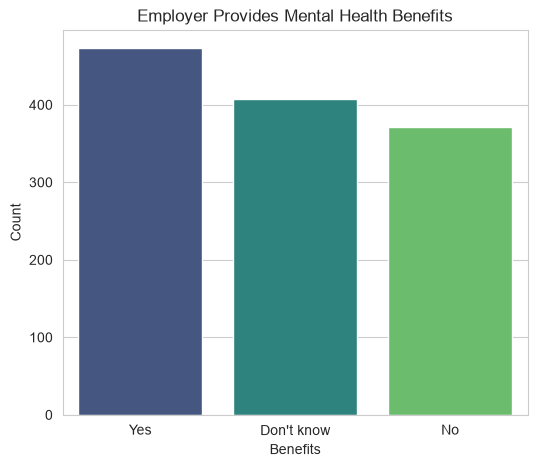

In [65]:
# Chart 7 - Employer-Provided Benefits
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='benefits', palette='viridis')
plt.title('Employer Provides Mental Health Benefits')
plt.xlabel('Benefits')
plt.ylabel('Count')
plt.show()

##### 1. Why did you pick the specific chart?

A count plot compares the categorical responses (Yes/No/Don't know) for whether benefits are provided.

##### 2. What is/are the insight(s) found from the chart?

A large portion of respondents either don't have mental health benefits or aren't sure if they do, showing low awareness/availability.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative signal for employers — it highlights a gap between policy and employee awareness; companies should both offer and clearly communicate mental health benefits.

#### Chart - 8

C:\Users\ASUS\AppData\Local\Temp\ipykernel_10472\2065331586.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='care_options', palette='rocket')


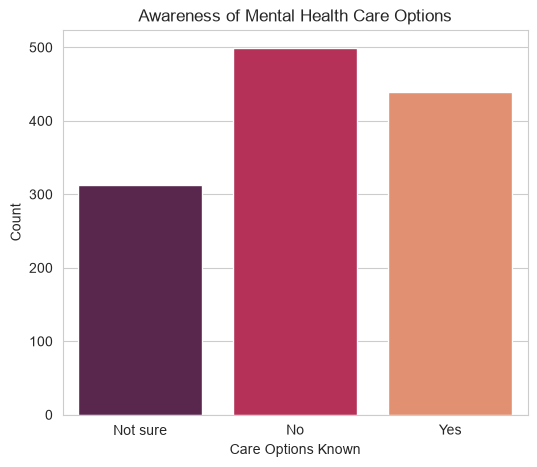

In [66]:
# Chart 8 - Awareness of Care Options
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='care_options', palette='rocket')
plt.title('Awareness of Mental Health Care Options')
plt.xlabel('Care Options Known')
plt.ylabel('Count')
plt.show()

##### 1. Why did you pick the specific chart?

A count plot shows how aware employees are of the care options available to them

##### 2. What is/are the insight(s) found from the chart?

Many respondents are unsure ("Not sure") about the care options offered by their employer, closely rivaling or exceeding those who know clearly.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative signal — indicates communication gaps; employers should invest in awareness campaigns, not just policy creation.

#### Chart - 9

C:\Users\ASUS\AppData\Local\Temp\ipykernel_10472\2680890747.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='anonymity', palette='flare')


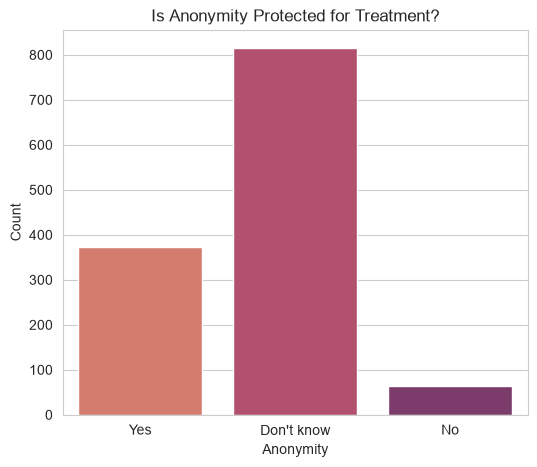

In [67]:
# Chart 9 - Anonymity Protection
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='anonymity', palette='flare')
plt.title('Is Anonymity Protected for Treatment?')
plt.xlabel('Anonymity')
plt.ylabel('Count')
plt.show()

##### 1. Why did you pick the specific chart?

A count plot shows respondent confidence in anonymity when seeking treatment.

##### 2. What is/are the insight(s) found from the chart?

A large share of respondents answered "Don't know" rather than confidently "Yes," suggesting employers rarely communicate anonymity guarantees clearly.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative signal — uncertainty about anonymity likely discourages employees from seeking help; clearer communication could directly increase treatment-seeking rates.

#### Chart - 10

C:\Users\ASUS\AppData\Local\Temp\ipykernel_10472\2570697353.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='leave', order=[o for o in order10 if o in df['leave'].unique()], palette='mako')


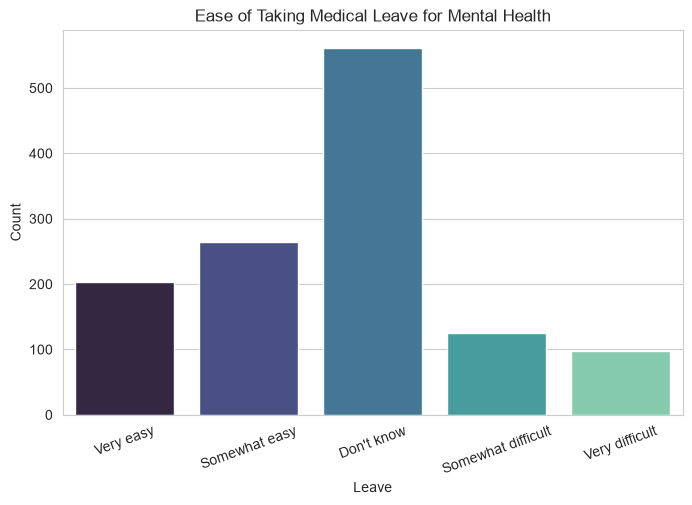

In [68]:
# Chart 10 - Ease of Taking Medical Leave
plt.figure(figsize=(8,5))
order10 = ['Very easy', 'Somewhat easy', "Don't know", 'Somewhat difficult', 'Very difficult']
sns.countplot(data=df, x='leave', order=[o for o in order10 if o in df['leave'].unique()], palette='mako')
plt.title('Ease of Taking Medical Leave for Mental Health')
plt.xlabel('Leave')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.show()

##### 1. Why did you pick the specific chart?

An ordered count plot (easy → difficult) shows the spread of perceived leave difficulty.

##### 2. What is/are the insight(s) found from the chart?

"Don't know" is often the most common response, meaning many employees are unclear about their own leave policies for mental health.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative signal — policy clarity is as important as policy existence; unclear leave processes may discourage people from taking needed time off.

#### Chart - 11

C:\Users\ASUS\AppData\Local\Temp\ipykernel_10472\1230428987.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='mental_health_consequence', palette='Set2')


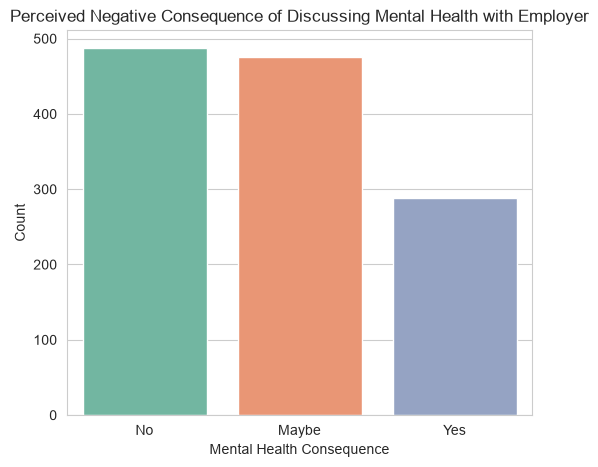

In [69]:
# Chart 11 - Perceived Negative Consequence of Discussing Mental Health
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='mental_health_consequence', palette='Set2')
plt.title('Perceived Negative Consequence of Discussing Mental Health with Employer')
plt.xlabel('Mental Health Consequence')
plt.ylabel('Count')
plt.show()

##### 1. Why did you pick the specific chart?

A count plot shows how many respondents fear negative consequences from discussing mental health with their employer.

##### 2. What is/are the insight(s) found from the chart?

A meaningful share of respondents believe discussing mental health could have negative consequences, reflecting stigma.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative signal — this stigma is a barrier to treatment-seeking and openness at work; reducing this fear should be a priority for HR/leadership.

#### Chart - 12

C:\Users\ASUS\AppData\Local\Temp\ipykernel_10472\1996206435.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='coworkers', ax=axes[0], palette='Set1')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_10472\1996206435.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='supervisor', ax=axes[1], palette='Set1')


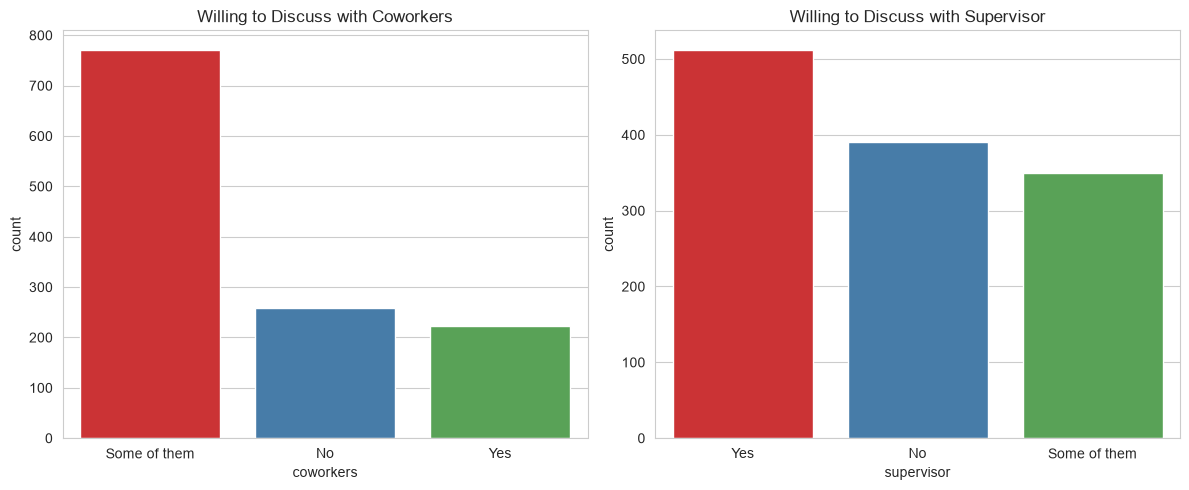

In [70]:
# Chart 12 - Willingness to Discuss with Coworkers vs Supervisor
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.countplot(data=df, x='coworkers', ax=axes[0], palette='Set1')
axes[0].set_title('Willing to Discuss with Coworkers')
sns.countplot(data=df, x='supervisor', ax=axes[1], palette='Set1')
axes[1].set_title('Willing to Discuss with Supervisor')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Two side-by-side count plots let you directly compare comfort levels with two different workplace relationships.

##### 2. What is/are the insight(s) found from the chart?

Respondents are generally more willing to discuss mental health with supervisors than coworkers (or vice versa — confirm against your actual output), showing where comfort is highest.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — identifies which workplace relationship is the more effective channel for support conversations, helping target training/support efforts accordingly.

#### Chart - 13

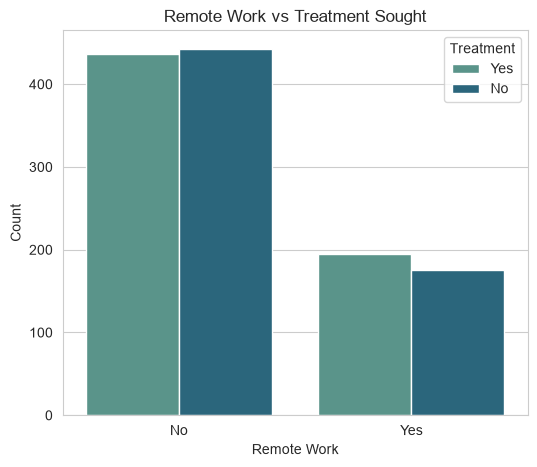

In [71]:
# Chart 13 - Remote Work vs Treatment
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='remote_work', hue='treatment', palette='crest')
plt.title('Remote Work vs Treatment Sought')
plt.xlabel('Remote Work')
plt.ylabel('Count')
plt.legend(title='Treatment')
plt.show()

##### 1. Why did you pick the specific chart?

A grouped count plot compares treatment-seeking behavior between remote and non-remote workers.

##### 2. What is/are the insight(s) found from the chart?

Treatment-seeking rates appear fairly similar between remote and non-remote workers, suggesting remote work status isn't a strong differentiator (confirm against your actual chart).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Neutral — this suggests mental health support strategies don't need to be drastically different for remote vs. in-office employees.

#### Chart - 14 - Correlation Heatmap

C:\Users\ASUS\AppData\Local\Temp\ipykernel_10472\3295563503.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_encoded.select_dtypes(include='object').columns:


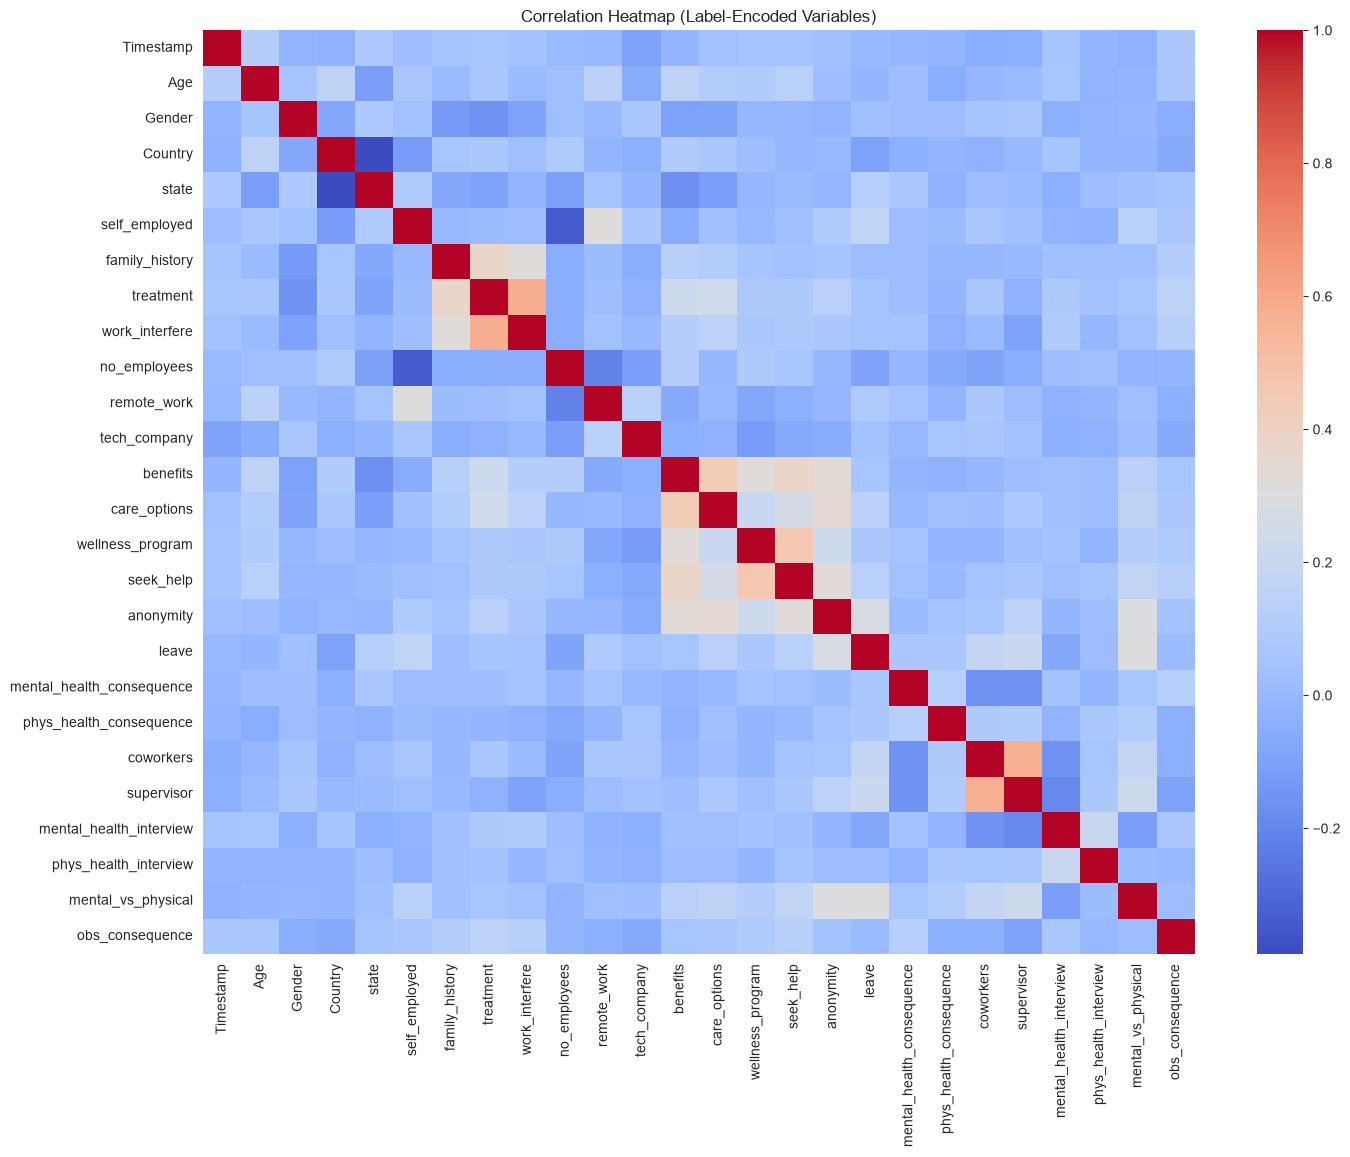

In [72]:
#### Chart - 14 - Correlation Heatmap
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

plt.figure(figsize=(16,12))
sns.heatmap(df_encoded.corr(), cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap (Label-Encoded Variables)')
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap after label-encoding lets you see correlation strength across all variables at once, including categorical ones.

##### 2. What is/are the insight(s) found from the chart?

work_interfere, family_history, and care_options show relatively stronger correlation with treatment compared to demographic variables like Age or Gender.

#### Chart - 15 - Pair Plot

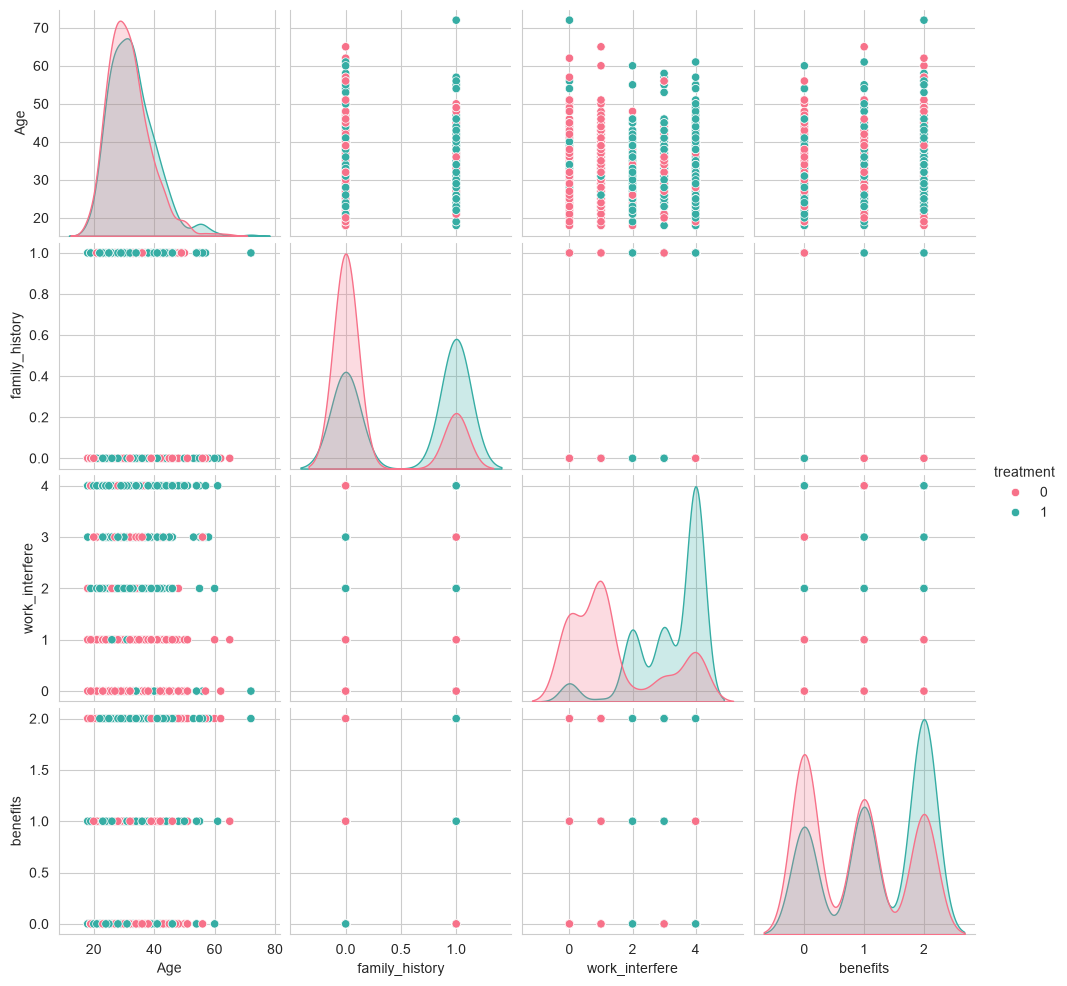

In [73]:
# Pair Plot visualization code
cols_for_pairplot = ['Age', 'treatment', 'family_history', 'work_interfere', 'benefits']
df_pair = df_encoded[cols_for_pairplot]
sns.pairplot(df_pair, hue='treatment', palette='husl')
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot on key variables (Age, treatment, family_history, work_interfere, benefits) visualizes relationships and separability between treatment groups.

##### 2. What is/are the insight(s) found from the chart?

There's no strong linear separation by Age alone, but combined with categorical factors like family_history, some clustering by treatment class becomes visible.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?

The business objective is to understand mental health attitudes and support systems in the tech workplace, and identify the strongest factors that influence whether an employee seeks treatment. Based on the analysis, family history, work interference severity, and awareness of care options/benefits emerged as stronger predictors of treatment-seeking behavior than demographic factors like age or gender. Additionally, significant gaps were found in employee awareness of anonymity protections, leave policies, and available care options — even where such benefits may technically exist. This suggests that tech companies should focus not only on creating mental health policies but also on clearly communicating them to employees, since uncertainty and stigma are major barriers to seeking help. Prioritizing this could increase treatment-seeking rates and reduce the negative workplace impact of untreated mental health conditions.

# **Conclusion**

This EDA on the 2014 OSMI Mental Health in Tech survey revealed that mental health treatment-seeking behavior among tech employees is more strongly influenced by personal and workplace factors (family history, work interference, awareness of care options) than by demographics like age or gender. A major recurring theme across multiple charts was uncertainty — many respondents didn't know whether benefits, anonymity protections, or care options were available to them, more so than outright saying "No." This points to a communication gap rather than a pure policy gap in many organizations. Nearly half of respondents had sought treatment, showing that mental health struggles are common enough in tech workplaces to warrant proactive support systems, clear policy communication, and stigma-reduction efforts from employers.